# Model evaluation — Congestion fee 

**Task :** Compare how well three model types predict **CBD congestion fee** (`has_congestion_fee`), using a **Confusion Matrix**, **accuracy**, and **F1 score**.

**Models compared**
- **Logistic regression** (baseline)
- **Random Forest** 
- **XGBoost classifier**

**Outputs**
- **Confusion matrix** 
- **Accuracy** 
- **F1 Score**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000

In [2]:
# load data and sample
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data = data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

# drop unnecessary columns and encode categoricals
y_congestion = data["has_congestion_fee"]
y_duration = data["trip_duration_min"]

drop_cols = [
    "trip_duration_min",
    "has_congestion_fee",
    "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    if X[col].dtype.name == "category":
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])

X_train, X_test, _, _, y_train, y_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_congestion,
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

print(f"Train {X_train.shape[0]:,} | Test {X_test.shape[0]:,} | Features {X_train.shape[1]}")

Train 400,000 | Test 100,000 | Features 21


In [4]:
# train models and fit

# Logistic Regression
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=2500, class_weight="balanced")
lr_model.fit(X_train_lr, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


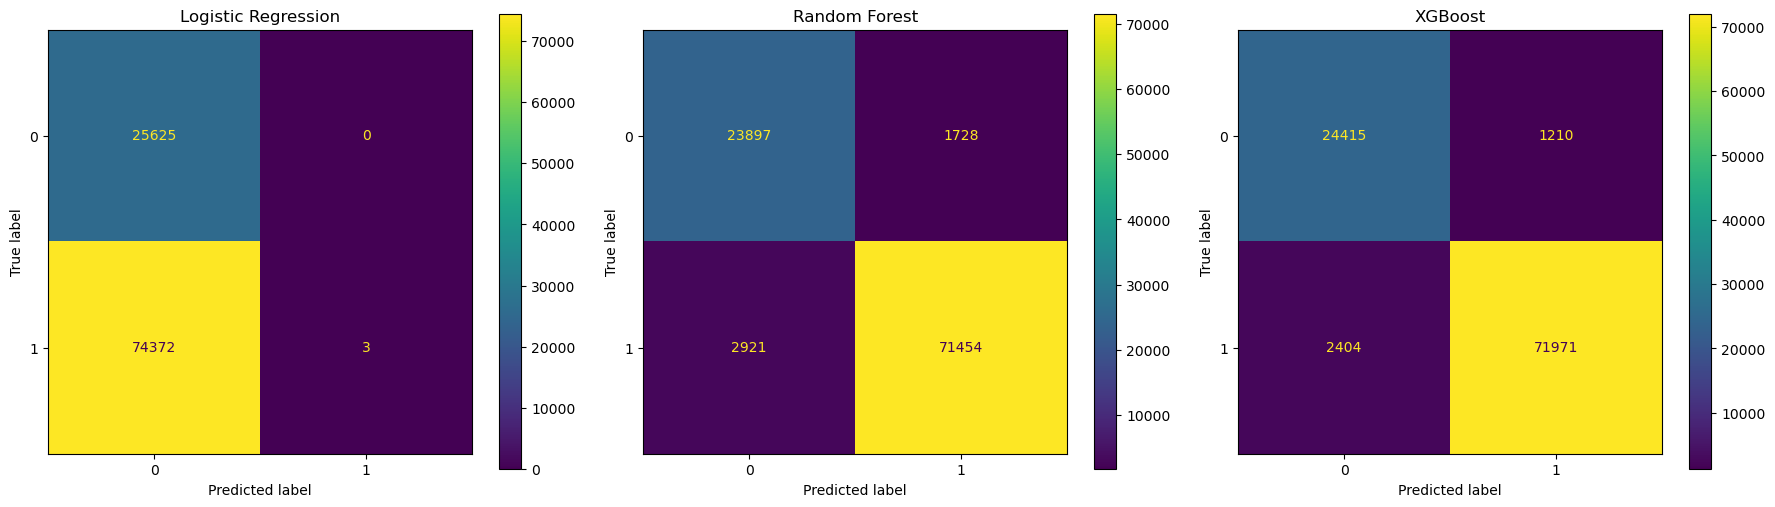

In [8]:
# plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [9]:
# compare metrics (accuracy, F1-score)
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}   

results = []
for name, model in models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_lr)
    else:
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})

print("\nModel Performance:")
for result in results:
    print(f"    {result['Model']}: Accuracy = {result['Accuracy']:.4f}, F1 Score = {result['F1 Score']:.4f}")


Model Performance:
    Logistic Regression: Accuracy = 0.6673, F1 Score = 0.7469
    Random Forest: Accuracy = 0.9535, F1 Score = 0.9685
    XGBoost: Accuracy = 0.9639, F1 Score = 0.9755


# Takeaways

- XGBoost achieved the strongest overall performance, with the highest F1 score (0.9755), indicating a better balance between detecting congestion fees and avoiding false predictions.
    
- Random Forest also performed well, improving over the baseline logistic regression by capturing nonlinear relationships in the data. With an F1 score of 0.9685, Random Forest is a close competitor to XGBoost.

- The confusion matrices show that advanced models reduce both false positives (incorrectly predicting a fee) and false negatives (missing a real fee), which is important for minimizing incorrect charges and lost revenue.

/var/folders/vf/l96lxy_5483b1bhjj3dxn9900000gn/T/ipykernel_68769/3615550955.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_acc = results.groupby("pickup_hour").apply(
/var/folders/vf/l96lxy_5483b1bhjj3dxn9900000gn/T/ipykernel_68769/3615550955.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_f1 = results.groupby("pickup_hour").apply(


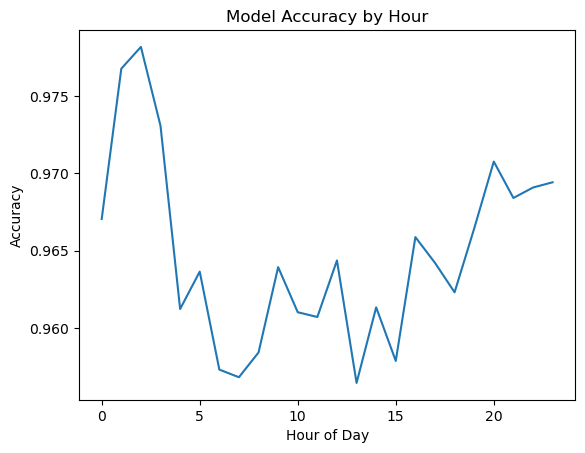

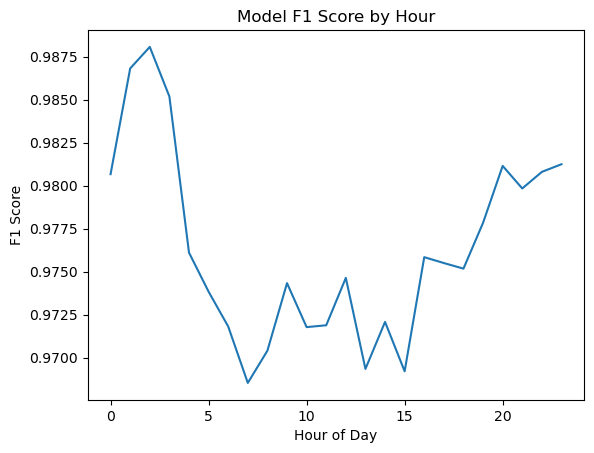

In [10]:
# get predictions from your best model
y_pred = xgb_model.predict(X_test)

# make sure X_test is a DataFrame and has pickup_hour
results = X_test.copy()
results["actual"] = y_test
results["pred"] = y_pred

# accuracy by hour
hourly_acc = results.groupby("pickup_hour").apply(
    lambda x: (x["actual"] == x["pred"]).mean()
)

# F1 by hour
hourly_f1 = results.groupby("pickup_hour").apply(
    lambda x: f1_score(x["actual"], x["pred"])
)

# plot
plt.figure()
hourly_acc.plot()
plt.title("Model Accuracy by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
hourly_f1.plot()
plt.title("Model F1 Score by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("F1 Score")
plt.show()

Model performance varies slightly by hour, with lower accuracy during peak traffic times (late afternoon and evening). This suggests that congestion patterns during rush hours are more complex and harder for the model to predict. Performance is higher during off-peak hours, where traffic conditions are more stable.